In [1]:
#!pip uninstall torch torchvision torchaudio matplotlib seaborn --y

In [2]:
#!pip install torch torchvision torchaudio matplotlib seaborn

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
# Training transforms (with augmentation)
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# Dev/Test transforms (no augmentation)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

In [6]:
data_dir = "./data"

train_full = torchvision.datasets.CIFAR10(
    root=data_dir, train=True, download=True, transform=transform_train
)

test_full = torchvision.datasets.CIFAR10(
    root=data_dir, train=False, download=True, transform=transform_test
)

100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


In [7]:
# Combine CIFAR-10 train (50k) + test (10k) = 60k total
full_dataset = torch.utils.data.ConcatDataset([train_full, test_full])

TOTAL = len(full_dataset)
TRAIN_SIZE = 50000
DEV_SIZE = 6000
TEST_SIZE = 4000   # assignment requirement

trainset, devset, testset, _ = random_split(
    full_dataset,
    [TRAIN_SIZE, DEV_SIZE, TEST_SIZE, TOTAL - (TRAIN_SIZE + DEV_SIZE + TEST_SIZE)]
)

print("Train set:", len(trainset))
print("Dev set:", len(devset))
print("Test set:", len(testset))

Train set: 50000
Dev set: 6000
Test set: 4000


In [8]:
batch_size = 128

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
devloader = DataLoader(devset, batch_size=batch_size, shuffle=False)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32→16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16→8

            nn.Dropout(0.3)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
model

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout(p=0.3, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_fe

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
epochs = 50

train_losses = []
dev_losses = []
train_accs = []
dev_accs = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    train_losses.append(running_loss / len(trainloader))
    train_accs.append(100 * correct / total)

    model.eval()
    dev_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in devloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            dev_loss += loss.item()

            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

    dev_losses.append(dev_loss / len(devloader))
    dev_accs.append(100 * correct / total)

    print(f"Epoch [{epoch+1}/{epochs}]  "
          f"Train Loss: {train_losses[-1]:.4f}  Dev Loss: {dev_losses[-1]:.4f}  "
          f"Train Acc: {train_accs[-1]:.2f}%  Dev Acc: {dev_accs[-1]:.2f}%")

Epoch [1/50]  Train Loss: 1.7651  Dev Loss: 1.4014  Train Acc: 33.99%  Dev Acc: 48.08%
Epoch [2/50]  Train Loss: 1.4580  Dev Loss: 1.2112  Train Acc: 46.07%  Dev Acc: 56.28%
Epoch [3/50]  Train Loss: 1.3396  Dev Loss: 1.1571  Train Acc: 50.99%  Dev Acc: 59.93%
Epoch [4/50]  Train Loss: 1.2739  Dev Loss: 1.0886  Train Acc: 53.96%  Dev Acc: 60.03%
Epoch [5/50]  Train Loss: 1.2204  Dev Loss: 0.9994  Train Acc: 55.85%  Dev Acc: 64.37%
Epoch [6/50]  Train Loss: 1.1846  Dev Loss: 0.9640  Train Acc: 57.27%  Dev Acc: 66.72%
Epoch [7/50]  Train Loss: 1.1530  Dev Loss: 0.9647  Train Acc: 58.67%  Dev Acc: 65.73%
Epoch [8/50]  Train Loss: 1.1237  Dev Loss: 0.9317  Train Acc: 59.64%  Dev Acc: 66.58%
Epoch [9/50]  Train Loss: 1.0940  Dev Loss: 0.9032  Train Acc: 60.78%  Dev Acc: 68.28%
Epoch [10/50]  Train Loss: 1.0719  Dev Loss: 0.8678  Train Acc: 61.59%  Dev Acc: 69.85%
Epoch [11/50]  Train Loss: 1.0575  Dev Loss: 0.8667  Train Acc: 61.93%  Dev Acc: 69.78%
Epoch [12/50]  Train Loss: 1.0376  Dev Lo

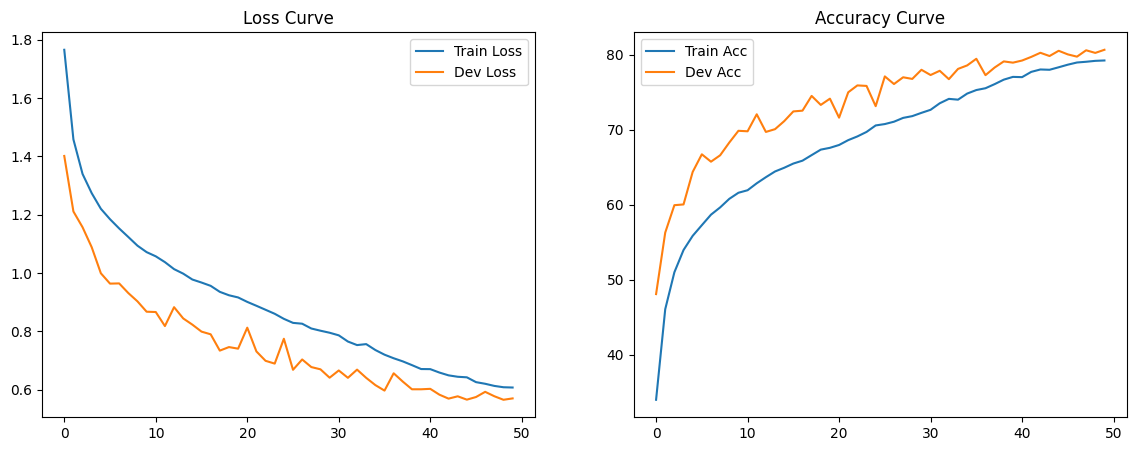

In [12]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(dev_losses, label="Dev Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(dev_accs, label="Dev Acc")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

<Figure size 1000x1000 with 0 Axes>

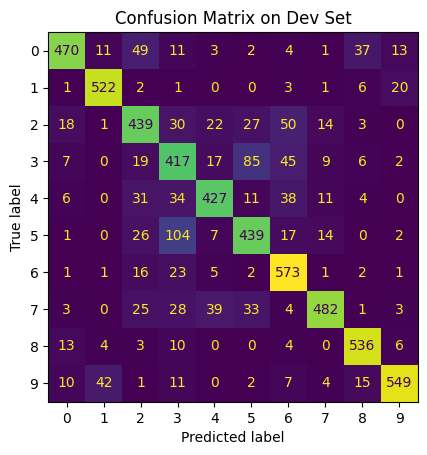

In [13]:
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in devloader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,10))   # <-- Set figure size here

disp = ConfusionMatrixDisplay(cm)
disp.plot(colorbar=False)     # <-- Remove figsize argument, avoid overlapping colorbar

plt.title("Confusion Matrix on Dev Set")
plt.show()

In [14]:
classes = train_full.classes  # CIFAR-10 class names

print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

    airplane       0.89      0.78      0.83       601
  automobile       0.90      0.94      0.92       556
        bird       0.72      0.73      0.72       604
         cat       0.62      0.69      0.65       607
        deer       0.82      0.76      0.79       562
         dog       0.73      0.72      0.73       610
        frog       0.77      0.92      0.84       625
       horse       0.90      0.78      0.83       618
        ship       0.88      0.93      0.90       576
       truck       0.92      0.86      0.89       641

    accuracy                           0.81      6000
   macro avg       0.81      0.81      0.81      6000
weighted avg       0.81      0.81      0.81      6000



In [15]:
model.eval()
final_predictions = []

with torch.no_grad():
    for images, _ in testloader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        final_predictions.extend(preds.cpu().numpy())

df = pd.DataFrame({
    "image_id": list(range(len(final_predictions))),
    "predicted_class": [classes[p] for p in final_predictions]
})

df.to_csv("CIFAR10_Test_Predictions.csv", index=False)

df.head()

,image_id,predicted_class
0,0,cat
1,1,cat
2,2,airplane
3,3,deer
4,4,horse
